## <font color="maroon"><h4 align="center">Pandas Group By</font>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**In this tutorial we are going to look at weather data from various cities and see how group by can be used to run some analytics.**

In [1]:
import pandas as pd
df = pd.read_csv("weather_by_cities.csv")
df

,day,city,temperature,windspeed,event
0,1/1/2024,new york,32,6,Rain
1,1/2/2024,new york,36,7,Sunny
2,1/3/2024,new york,28,12,Snow
3,1/4/2024,new york,33,7,Sunny
4,1/1/2024,dubai,90,5,Sunny
5,1/2/2024,dubai,85,12,Fog
6,1/3/2024,dubai,87,15,Fog
7,1/4/2024,dubai,92,5,Rain
8,1/1/2024,paris,45,20,Sunny
9,1/2/2024,paris,50,13,Cloudy


### For this dataset, get following answers,
#### 1. What was the maximum temperature in each of these 3 cities?
#### 2. What was the average windspeed in each of these 3 cities?


In [14]:
# maximum temperature in each of these 3 cities

df.groupby('city')[['temperature']].max()

,temperature
city,
dubai,92
new york,36
paris,54


In [15]:
# average windspeed in each of these 3 cities

df.groupby('city')[['windspeed']].mean()

,windspeed
city,
dubai,9.25
new york,8.00
paris,12.75


In [10]:
g = df.groupby("city")
g

**DataFrameGroupBy object looks something like below,**

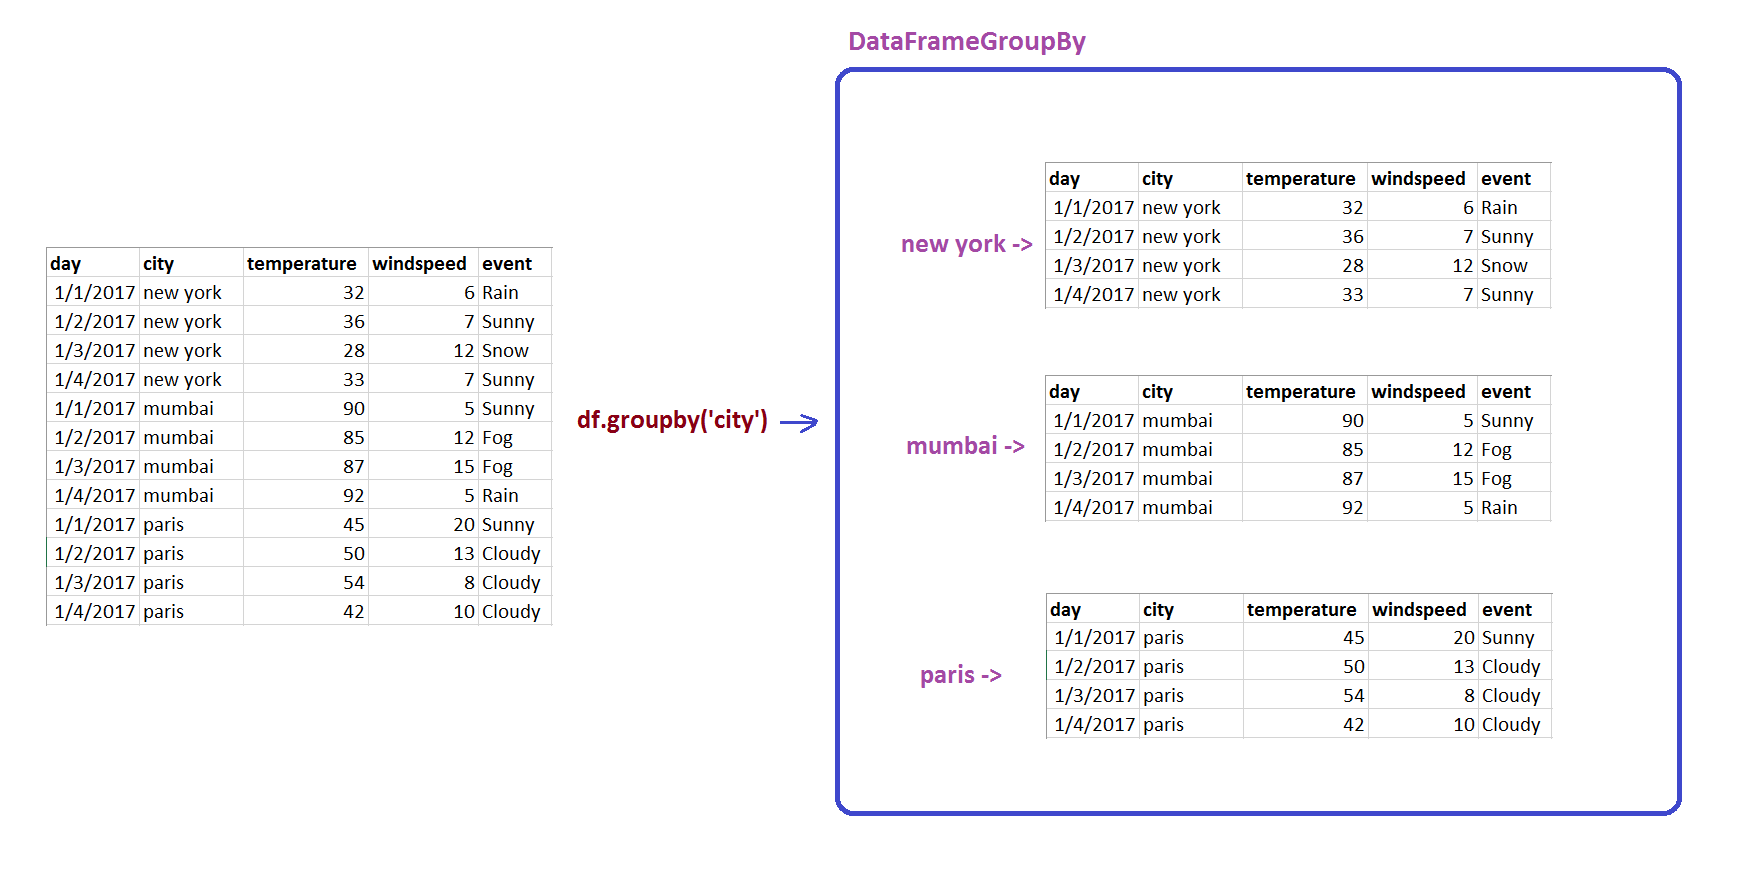

In [5]:
for city, data in g:
    print("city:",city)
    print("\n")
    print("data:",data)

city: dubai


data:         day   city  temperature  windspeed  event
4  1/1/2024  dubai           90          5  Sunny
5  1/2/2024  dubai           85         12    Fog
6  1/3/2024  dubai           87         15    Fog
7  1/4/2024  dubai           92          5   Rain
city: new york


data:         day      city  temperature  windspeed  event
0  1/1/2024  new york           32          6   Rain
1  1/2/2024  new york           36          7  Sunny
2  1/3/2024  new york           28         12   Snow
3  1/4/2024  new york           33          7  Sunny
city: paris


data:          day   city  temperature  windspeed   event
8   1/1/2024  paris           45         20   Sunny
9   1/2/2024  paris           50         13  Cloudy
10  1/3/2024  paris           54          8  Cloudy
11  1/4/2024  paris           42         10  Cloudy


**This is similar to SQL,**

> SELECT * from weather_data GROUP BY city

In [6]:
g.get_group('paris')

,day,city,temperature,windspeed,event
8,1/1/2024,paris,45,20,Sunny
9,1/2/2024,paris,50,13,Cloudy
10,1/3/2024,paris,54,8,Cloudy
11,1/4/2024,paris,42,10,Cloudy


In [7]:
g.min()

,day,temperature,windspeed,event
city,,,,
dubai,1/1/2024,85,5,Fog
new york,1/1/2024,28,6,Rain
paris,1/1/2024,42,8,Cloudy


In [ ]:
g.mean(numeric_only=True)

,temperature,windspeed
city,,
dubai,88.50,9.25
new york,32.25,8.00
paris,47.75,12.75


**This method of splitting your dataset in smaller groups and then applying an operation
(such as min or max) to get aggregate result is called Split-Apply-Combine. It is illustrated in a diagram below**

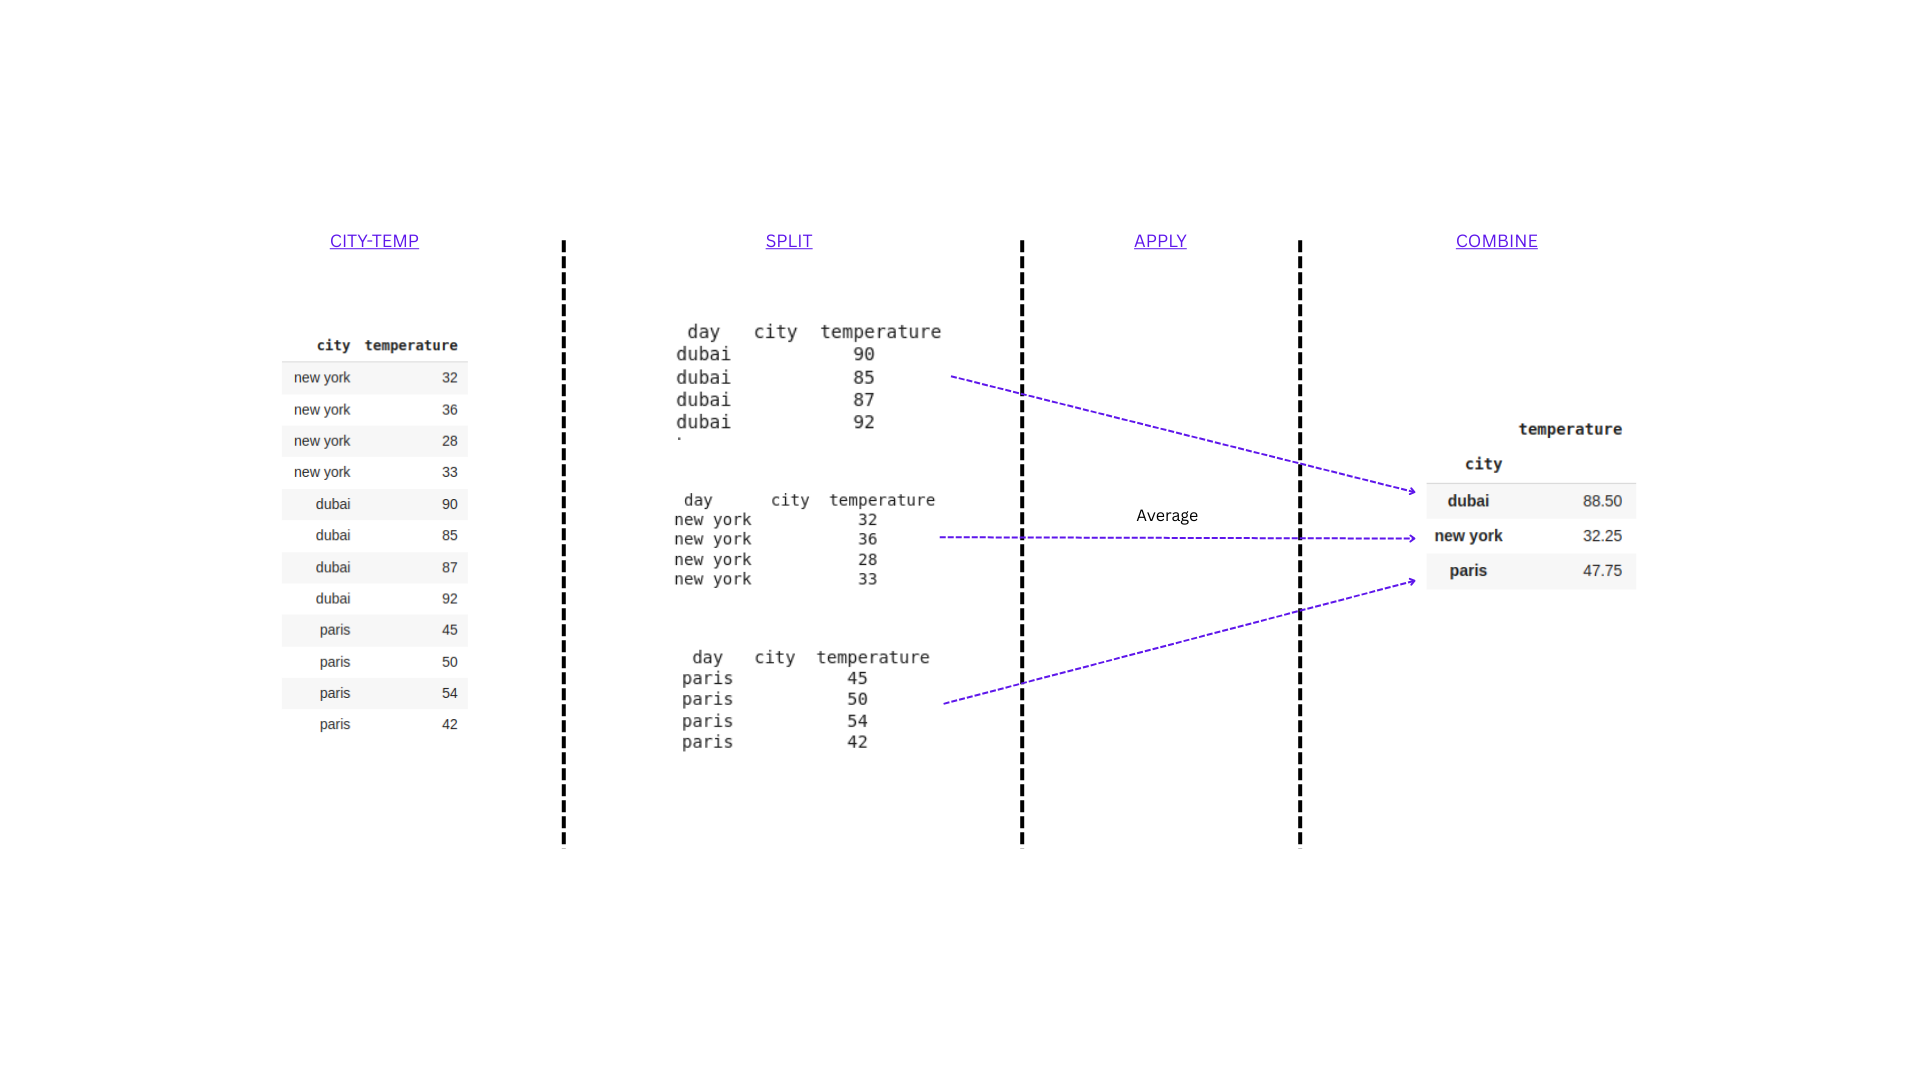

In [ ]:
g.min()

,day,temperature,windspeed,event
city,,,,
dubai,1/1/2024,85,5,Fog
new york,1/1/2024,28,6,Rain
paris,1/1/2024,42,8,Cloudy


In [ ]:
g.describe()

temperature                                                   \
               count   mean       std   min    25%   50%    75%   max   
city                                                                    
dubai            4.0  88.50  3.109126  85.0  86.50  88.5  90.50  92.0   
new york         4.0  32.25  3.304038  28.0  31.00  32.5  33.75  36.0   
paris            4.0  47.75  5.315073  42.0  44.25  47.5  51.00  54.0   

         windspeed                                                 
             count   mean       std  min   25%   50%    75%   max  
city                                                               
dubai          4.0   9.25  5.057997  5.0  5.00   8.5  12.75  15.0  
new york       4.0   8.00  2.708013  6.0  6.75   7.0   8.25  12.0  
paris          4.0  12.75  5.251984  8.0  9.50  11.5  14.75  20.0

In [ ]:
g.size()

,0
city,
dubai,4
new york,4
paris,4


In [ ]:
g.count()

,day,temperature,windspeed,event
city,,,,
dubai,4,4,4,4
new york,4,4,4,4
paris,4,4,4,4


,0
city,
dubai,"Axes(0.125,0.11;0.775x0.77)"
new york,"Axes(0.125,0.11;0.775x0.77)"
paris,"Axes(0.125,0.11;0.775x0.77)"


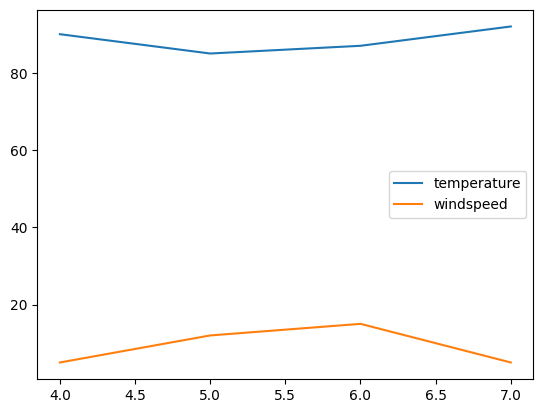

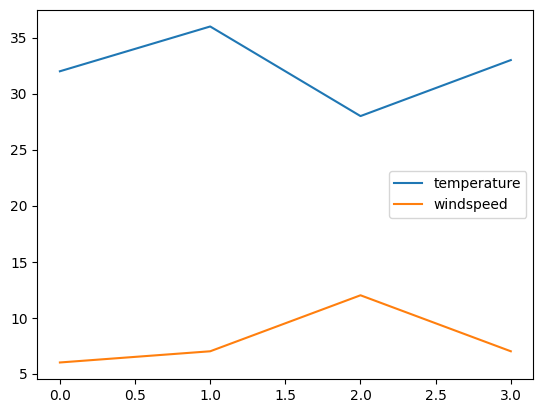

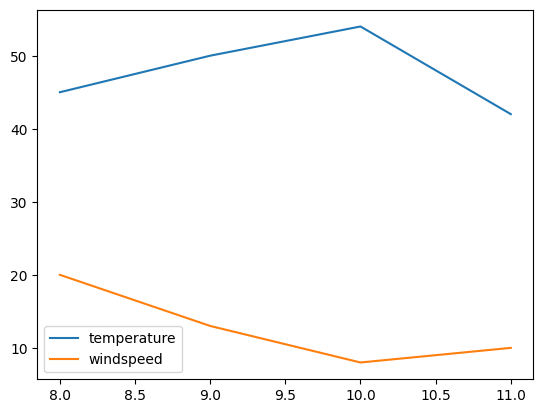

In [ ]:
%matplotlib inline
g.plot()

<h4>Group data using custom function: Let's say you want to group your data using custom function. Here the requirement is to create three groups<h4>
<ol>
    <li>Days when temperature was between 80 and 90</li>
    <li>Days when it was between 50 and 60</li>
    <li>Days when it was anything else</li>
</ol>

For this you need to write custom grouping function and pass that to groupby

In [11]:
def grouper(df, idx, col):
    if 80 <= df[col].loc[idx] <= 90:
        return '80-90'
    elif 50 <= df[col].loc[idx] <= 60:
        return '50-60'
    else:
        return 'others'

In [12]:
g = df.groupby(lambda x: grouper(df, x, 'temperature'))
g

In [13]:
for key, d in g:
    print("Group by Key: {}\n".format(key))
    print(d)

Group by Key: 50-60

         day   city  temperature  windspeed   event
9   1/2/2024  paris           50         13  Cloudy
10  1/3/2024  paris           54          8  Cloudy
Group by Key: 80-90

        day   city  temperature  windspeed  event
4  1/1/2024  dubai           90          5  Sunny
5  1/2/2024  dubai           85         12    Fog
6  1/3/2024  dubai           87         15    Fog
Group by Key: others

         day      city  temperature  windspeed   event
0   1/1/2024  new york           32          6    Rain
1   1/2/2024  new york           36          7   Sunny
2   1/3/2024  new york           28         12    Snow
3   1/4/2024  new york           33          7   Sunny
7   1/4/2024     dubai           92          5    Rain
8   1/1/2024     paris           45         20   Sunny
11  1/4/2024     paris           42         10  Cloudy
